# SECTION 1 — Environment Setup

# Heart Disease Classification Experiment

This notebook evaluates the performance of:

- Single classifiers
- CombinedClassifier aggregation

on the Heart Disease dataset.

Metrics:
- Accuracy
- F1-score
- Precision
- Recall

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


# SECTION 2 — Dataset Loading

In [2]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

path = dataset_download("johnsmith88/heart-disease-dataset")
df = pd.read_csv(os.path.join(path, "heart.csv"))
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# SECTION 3 — Exploratory Data Analysis

In [3]:
print(df.shape)
df.info()

(1025, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

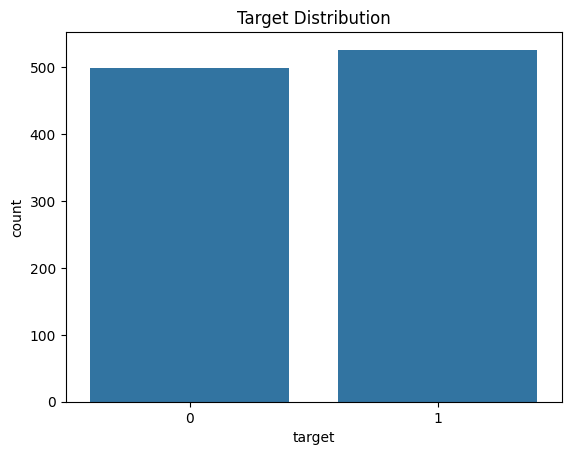

In [5]:
sns.countplot(x=df["target"])

plt.title("Target Distribution")
plt.show()

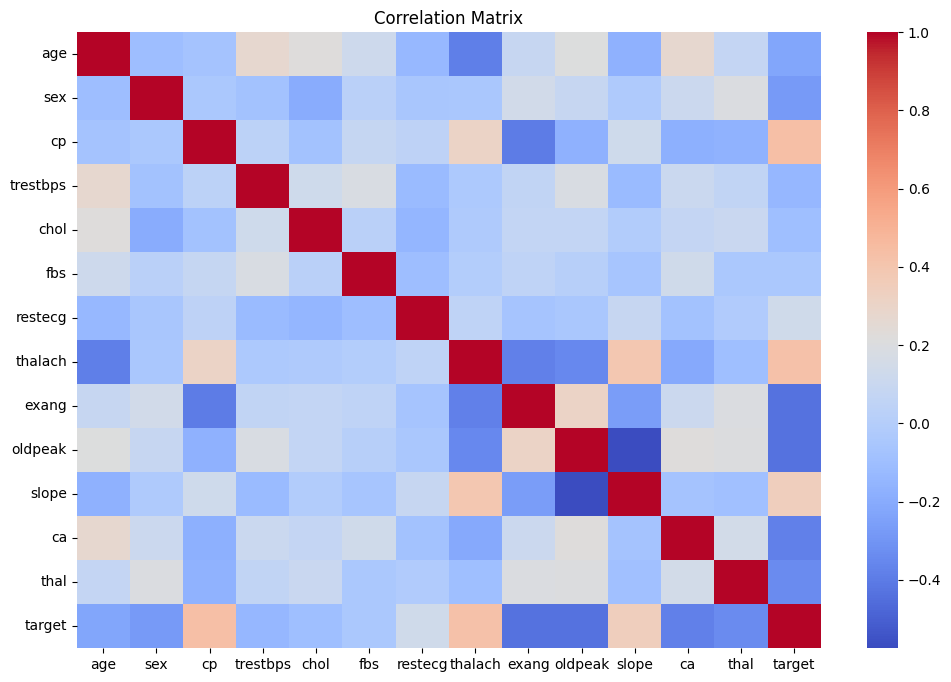

In [6]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

# SECTION 4 — Data Preprocessing

In [7]:
X = df.drop(columns=["target"])
y = df["target"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# SECTION 5 — Train Models

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "logistic_regression": LogisticRegression(),
    "random_forest_classifier": RandomForestClassifier(),
    "svc": SVC(probability=True),
    "k_neighbors_classifier": KNeighborsClassifier(),
    "gaussian_nb": GaussianNB(),
}

def evaluate_classification(y_true, y_pred):
    metrics = {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall"   : recall_score(y_true, y_pred, average='weighted'),
        "F1 Score" : f1_score(y_true, y_pred, average='weighted'),
    }
    return metrics

In [10]:
from cobra.combine_classifier import CombineClassifier

results = {}

combined_classifier = CombineClassifier(
    estimators=models.keys(),
    random_state=42,
)
start_fit = time.perf_counter()
combined_classifier.fit(X_train, y_train)
fit_time = time.perf_counter() - start_fit

start_pred = time.perf_counter()
y_pred_combine = combined_classifier.predict(X_test)
predict_time = time.perf_counter() - start_pred

metrics_combine = evaluate_classification(y_test, y_pred_combine)
results["combine_classifier"] = metrics_combine
print(f"Results for combine_classifier: {metrics_combine}\n")
print(f"Time computing : fit {fit_time}, predict {predict_time}")

search: 100%|██████████| 300/300 [00:01<00:00, 211.25it/s]

Results for combine_classifier: {'Accuracy': 0.9219512195121952, 'Precision': 0.9232948568703628, 'Recall': 0.9219512195121952, 'F1 Score': 0.921828290447853}

Time computing : fit 1.7752946669934317, predict 0.01017237501218915


In [11]:
combined_classifier.optimization_outputs_

{'method': 'grid',
 'optimizer': 'grid',
 'bandwidth': 9.598702341137123,
 'score': np.float64(0.056097560975609764),
 'history':      iter     score      risk  bandwidth
 0       0  0.463415  0.463415   0.001000
 1       1  0.463415  0.463415   0.034441
 2       2  0.463415  0.463415   0.067883
 3       3  0.463415  0.463415   0.101324
 4       4  0.463415  0.463415   0.134766
 ..    ...       ...       ...        ...
 295   295  0.056098  0.056098   9.866234
 296   296  0.056098  0.056098   9.899676
 297   297  0.056098  0.056098   9.933117
 298   298  0.056098  0.056098   9.966559
 299   299  0.056098  0.056098  10.000000
 
 [300 rows x 4 columns]}

In [12]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = evaluate_classification(y_test, y_pred)
    results[name] = metrics

In [13]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1 Score
random_forest_classifier,1.000000,1.000000,1.000000,1.000000
combine_classifier,0.921951,0.923295,0.921951,0.921828
logistic_regression,0.834146,0.844140,0.834146,0.832492
gaussian_nb,0.829268,0.831469,0.829268,0.828754
svc,0.717073,0.720263,0.717073,0.715267
k_neighbors_classifier,0.697561,0.698150,0.697561,0.697590


<Axes: xlabel='bandwidth', ylabel='score'>

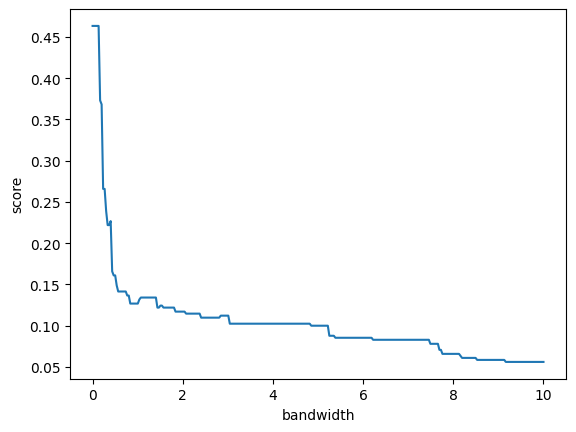

In [14]:
df_output = combined_classifier.optimization_outputs_['history']
sns.lineplot(df_output, x='bandwidth', y='score')

# SECTION 6 — External training

In [16]:
X_base, X_agg, y_base, y_agg = train_test_split(
    X_train,
    y_train,
    test_size=0.5,
    random_state=42,
    stratify=y_train
)

fit_models = {}
for name, model in models.items():
    model.fit(X_base, y_base)
    fit_models[name] = model

P_agg = np.column_stack([
    m.predict(X_agg)
    for m in fit_models.values()
])

P_test = np.column_stack([
    m.predict(X_test)
    for m in fit_models.values()
])

combined = CombineClassifier(
    estimators=fit_models.keys(),
    random_state=42,
)

combined.fit(
    X=P_agg,
    y=y_agg,
    as_predictions=True
)

y_pred = combined.predict(
    X=P_test
)

metrics_combine = evaluate_classification(y_test, y_pred)
metrics_combine


search: 100%|██████████| 300/300 [00:01<00:00, 216.36it/s]


{'Accuracy': 0.9170731707317074,
 'Precision': 0.9173721118654485,
 'Recall': 0.9170731707317074,
 'F1 Score': 0.9170257399292373}